One thing that matters for E5 specifically: it was trained with `"query: "` /
`"passage: "` prefixes, and the model card recommends the `"query: "` prefix for
classification/clustering use (not just retrieval). `fastembed`'s `query_embed()`
applies this automatically — that's why it's used below instead of `embed()`.


In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from fastembed import TextEmbedding

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import Normalizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    accuracy_score, ConfusionMatrixDisplay
)
from lightgbm import LGBMClassifier

/home/kibria/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
df = pd.read_csv('../deshimula_all_reviews_new.csv')
NUM_SAMPLES = 2552
sentiment_df = df[['content', 'vibe']][:NUM_SAMPLES]
sentiment_df.shape

(2552, 2)

In [3]:
X = sentiment_df['content']
y = sentiment_df['vibe']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")
print(y_train.value_counts())

Training samples: 2041, Testing samples: 511
vibe
Negative    1584
Positive     231
Mixed        226
Name: count, dtype: int64


In [4]:
embed_model = TextEmbedding(model_name="intfloat/multilingual-e5-large")
print("Embedding dim:", embed_model.embedding_size)

/tmp/ipykernel_469001/531737689.py:1: UserWarning: The model intfloat/multilingual-e5-large now uses mean pooling instead of CLS embedding. In order to preserve the previous behaviour, consider either pinning fastembed version to 0.5.1 or using `add_custom_model` functionality.
  embed_model = TextEmbedding(model_name="intfloat/multilingual-e5-large")


Embedding dim: 1024


In [5]:
# Embeddings are frozen/unsupervised, so this only needs to run once —
# cache to disk and reload on future runs instead of re-embedding.
import os
from tqdm import tqdm

MAX_CHARS = 512  # E5-large max; longer texts get truncated to avoid OOM
BATCH_SIZE = 64

def truncate(texts):
    return [t[:MAX_CHARS] if isinstance(t, str) else t for t in texts]

def embed_texts(texts, cache_path):
    if os.path.exists(cache_path):
        return np.load(cache_path)
    t0 = time.time()
    truncated = truncate(texts.tolist())
    all_vecs = []
    num_batches = (len(truncated) + BATCH_SIZE - 1) // BATCH_SIZE
    for i in tqdm(range(0, len(truncated), BATCH_SIZE), total=num_batches, desc="Embedding"):
        batch = truncated[i:i+BATCH_SIZE]
        all_vecs.extend(embed_model.query_embed(batch))
    vectors = np.array(all_vecs)
    print(f"Embedded {len(texts)} texts in {time.time() - t0:.1f}s -> {vectors.shape}")
    np.save(cache_path, vectors)
    return vectors

X_train_emb = embed_texts(X_train, "X_train_emb.npy")
X_test_emb = embed_texts(X_test, "X_test_emb.npy")
X_train_emb.shape, X_test_emb.shape

Embedding: 100%|██████████| 32/32 [21:18<00:00, 39.94s/it]


Embedded 2041 texts in 1278.0s -> (2041, 1024)


Embedding: 100%|██████████| 8/8 [04:28<00:00, 33.60s/it]

Embedded 511 texts in 268.8s -> (511, 1024)


((2041, 1024), (511, 1024))

In [6]:
# E5 embeddings are trained with a cosine-similarity objective ->
# L2-normalize before feeding a linear/logistic classifier.
# max_iter raised because dense embeddings converge slower than sparse TF-IDF.
logistic_pipeline = Pipeline([
    ('normalize', Normalizer()),
    ('classifier', LogisticRegression(max_iter=2000, random_state=42))
])

lgb_pipeline = Pipeline([
    ('normalize', Normalizer()),
    ('classifier', LGBMClassifier(random_state=42))
])

svc_pipeline = Pipeline([
    ('normalize', Normalizer()),
    ('classifier', SVC(kernel='rbf', C=1.0, random_state=42))
])

In [7]:
logistic_pipeline.fit(X_train_emb, y_train)
lgb_pipeline.fit(X_train_emb, y_train)
svc_pipeline.fit(X_train_emb, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.032593 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 261120
[LightGBM] [Info] Number of data points in the train set: 2041, number of used features: 1024
[LightGBM] [Info] Start training from score -2.200660
[LightGBM] [Info] Start training from score -0.253487
[LightGBM] [Info] Start training from score -2.178777
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


,steps,"[('normalize', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,norm,'l2'
,copy,True
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0


In [8]:
def evaluate(pipeline, name):
    preds = pipeline.predict(X_test_emb)
    accuracy = np.mean(preds == y_test)
    macro_f1 = f1_score(y_test, preds, average='macro')
    print(f"{name} - Accuracy: {accuracy:.4f}, Macro F1 Score: {macro_f1:.4f}")
    print(classification_report(y_test, preds, zero_division=0))
    return preds

logistic_preds = evaluate(logistic_pipeline, "Logistic Regression (e5-large)")
lgb_preds = evaluate(lgb_pipeline, "LightGBM (e5-large)")
svc_preds = evaluate(svc_pipeline, "SVC (e5-large)")

Logistic Regression (e5-large) - Accuracy: 0.8258, Macro F1 Score: 0.4925
              precision    recall  f1-score   support

       Mixed       0.00      0.00      0.00        57
    Negative       0.83      1.00      0.91       396
    Positive       0.79      0.45      0.57        58

    accuracy                           0.83       511
   macro avg       0.54      0.48      0.49       511
weighted avg       0.73      0.83      0.77       511

LightGBM (e5-large) - Accuracy: 0.8376, Macro F1 Score: 0.5298
              precision    recall  f1-score   support

       Mixed       0.50      0.02      0.03        57
    Negative       0.85      1.00      0.92       396
    Positive       0.76      0.55      0.64        58

    accuracy                           0.84       511
   macro avg       0.70      0.52      0.53       511
weighted avg       0.80      0.84      0.79       511



/home/kibria/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


SVC (e5-large) - Accuracy: 0.8513, Macro F1 Score: 0.5755
              precision    recall  f1-score   support

       Mixed       1.00      0.05      0.10        57
    Negative       0.86      1.00      0.92       396
    Positive       0.79      0.64      0.70        58

    accuracy                           0.85       511
   macro avg       0.88      0.56      0.58       511
weighted avg       0.86      0.85      0.81       511



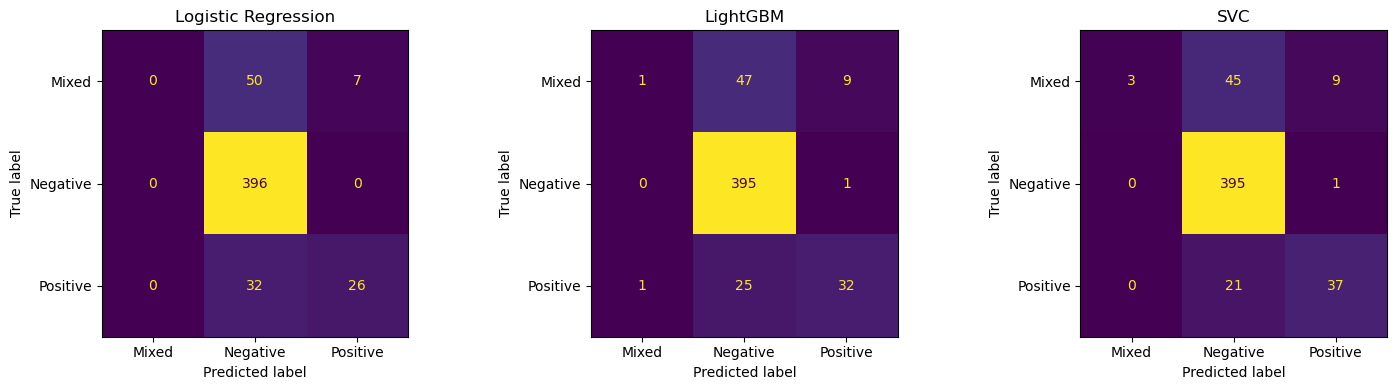

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, preds, name in zip(axes, [logistic_preds, lgb_preds, svc_preds], ["Logistic Regression", "LightGBM", "SVC"]):
    cm = confusion_matrix(y_test, preds, labels=sorted(y.unique()))
    ConfusionMatrixDisplay(cm, display_labels=sorted(y.unique())).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

In [10]:
# Embeddings are frozen (not fit on labels), so reusing the train+test
# embeddings together for CV is safe -- no need to re-embed per fold.
X_emb_full = np.vstack([X_train_emb, X_test_emb])
y_full = pd.concat([y_train, y_test])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'f1_macro']

logistic_cv_results = cross_validate(logistic_pipeline, X_emb_full, y_full, cv=cv, scoring=scoring)
lgb_cv_results = cross_validate(lgb_pipeline, X_emb_full, y_full, cv=cv, scoring=scoring)
svc_cv_results = cross_validate(svc_pipeline, X_emb_full, y_full, cv=cv, scoring=scoring)

for name, results in [("Logistic Regression", logistic_cv_results), ("LightGBM", lgb_cv_results), ("SVC", svc_cv_results)]:
    print(f"{name}:")
    print(f"  Accuracy: {results['test_accuracy'].mean():.4f} (+/- {results['test_accuracy'].std():.4f})")
    print(f"  F1 Macro: {results['test_f1_macro'].mean():.4f} (+/- {results['test_f1_macro'].std():.4f})")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.034370 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 261120
[LightGBM] [Info] Number of data points in the train set: 2041, number of used features: 1024
[LightGBM] [Info] Start training from score -2.200660
[LightGBM] [Info] Start training from score -0.253487
[LightGBM] [Info] Start training from score -2.178777


/home/kibria/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.032482 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 261120
[LightGBM] [Info] Number of data points in the train set: 2041, number of used features: 1024
[LightGBM] [Info] Start training from score -2.200660
[LightGBM] [Info] Start training from score -0.253487
[LightGBM] [Info] Start training from score -2.178777


/home/kibria/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.030591 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 261120
[LightGBM] [Info] Number of data points in the train set: 2042, number of used features: 1024
[LightGBM] [Info] Start training from score -2.201150
[LightGBM] [Info] Start training from score -0.253976
[LightGBM] [Info] Start training from score -2.174948


/home/kibria/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.036162 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 261118
[LightGBM] [Info] Number of data points in the train set: 2042, number of used features: 1024
[LightGBM] [Info] Start training from score -2.196735
[LightGBM] [Info] Start training from score -0.253976
[LightGBM] [Info] Start training from score -2.179267
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/home/kibria/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.030159 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 261120
[LightGBM] [Info] Number of data points in the train set: 2042, number of used features: 1024
[LightGBM] [Info] Start training from score -2.196735
[LightGBM] [Info] Start training from score -0.253976
[LightGBM] [Info] Start training from score -2.179267


/home/kibria/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Logistic Regression:
  Accuracy: 0.8268 (+/- 0.0054)
  F1 Macro: 0.4980 (+/- 0.0159)
LightGBM:
  Accuracy: 0.8370 (+/- 0.0065)
  F1 Macro: 0.5470 (+/- 0.0162)
SVC:
  Accuracy: 0.8452 (+/- 0.0082)
  F1 Macro: 0.5503 (+/- 0.0182)
